In [1]:
!apt-get install openjdk-11-jdk-headless -qq
!pip install -q pyspark findspark

In [2]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
# No need to download Spark—pip installation includes Spark JARs

import findspark
findspark.init()

from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("ColabSpark").getOrCreate()
spark

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


[Leakage Warning] Removing 1 column(s): ['AMIGR_BIN']
[Load] /content/drive/MyDrive/Infosys722/iteration4_prep_outputs/final_selected_table.parquet | shape=(25403, 38) | positive rate=0.152

[Train] Logistic Regression


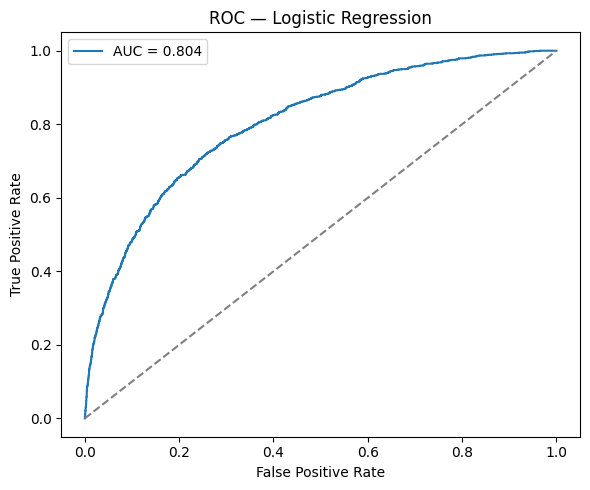

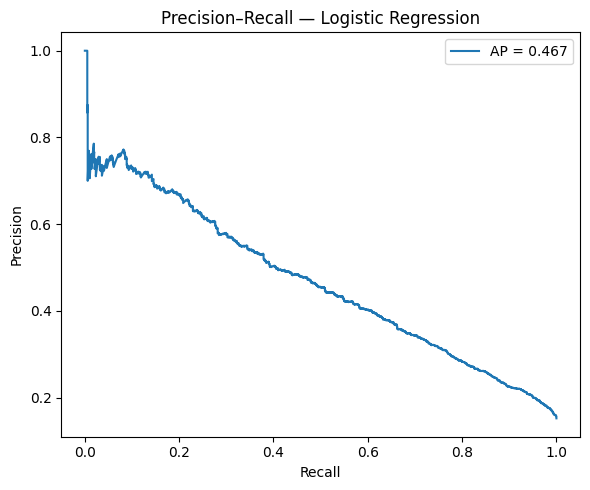

[Test] Logistic Regression: AUC=0.804 | AP=0.467 | F1=0.484


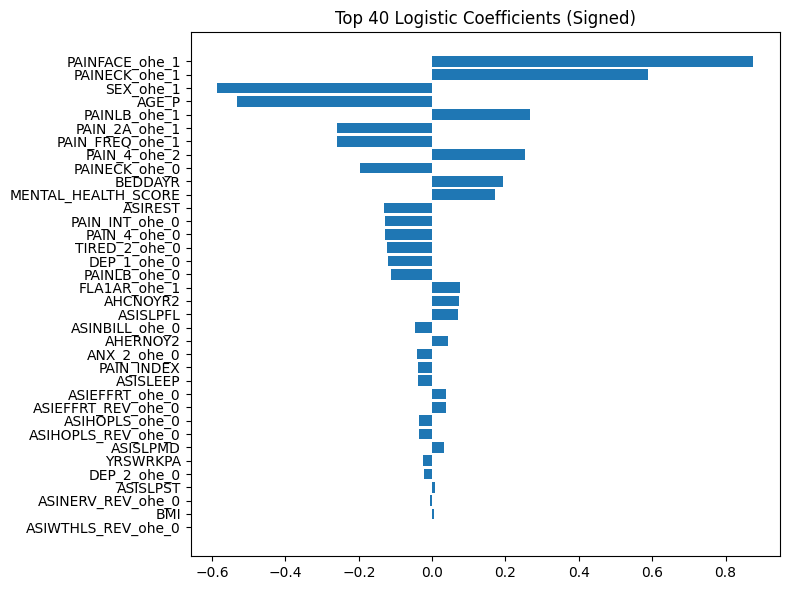


[Train] Decision Tree


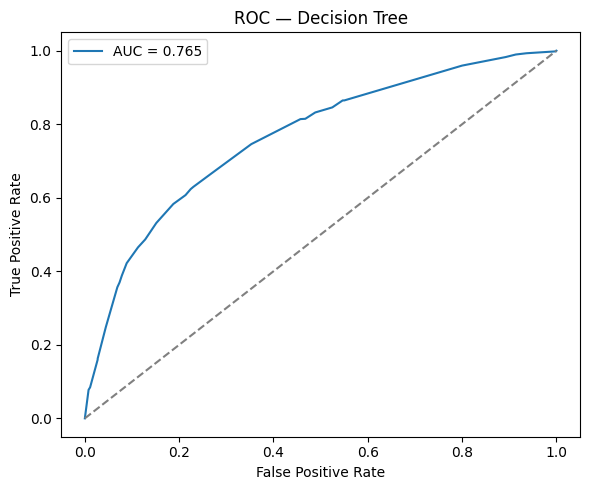

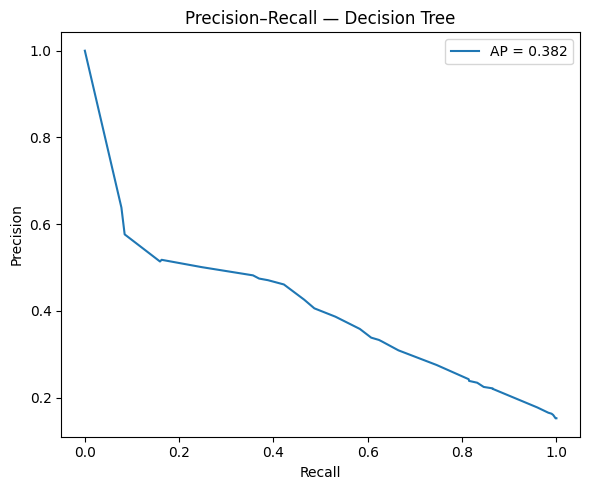

[Test] Decision Tree: AUC=0.765 | AP=0.382 | F1=0.448


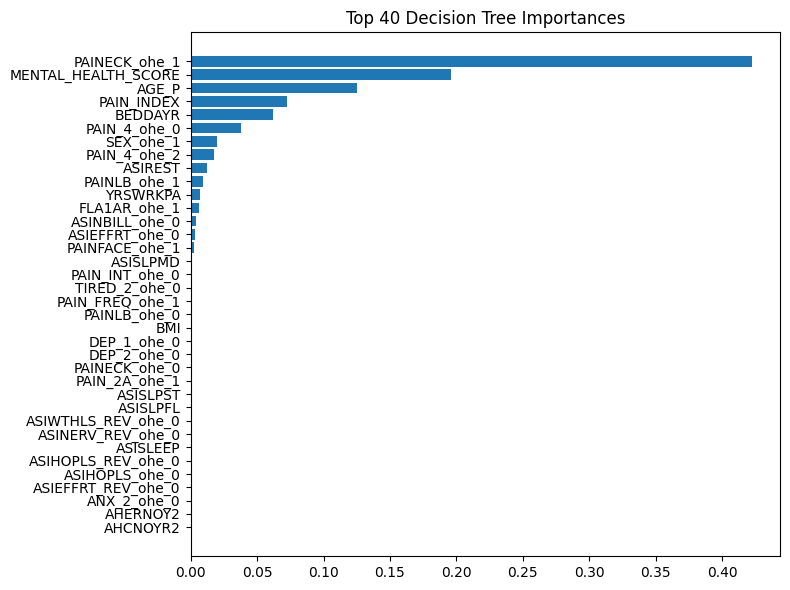


[Train] Random Forest


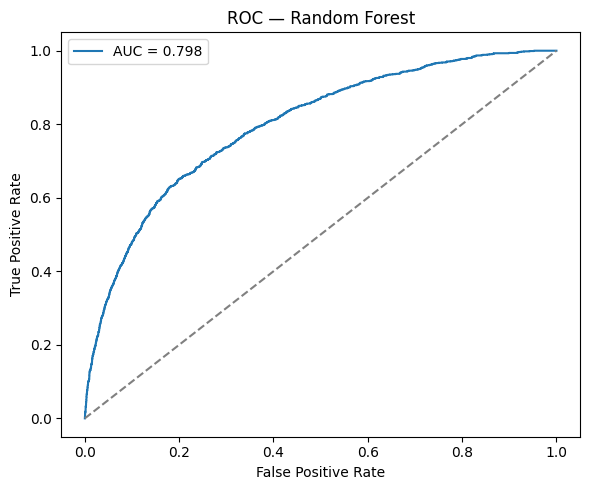

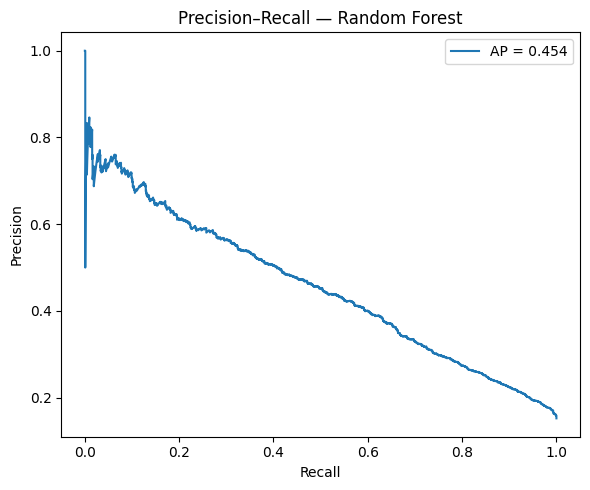

[Test] Random Forest: AUC=0.798 | AP=0.454 | F1=0.484


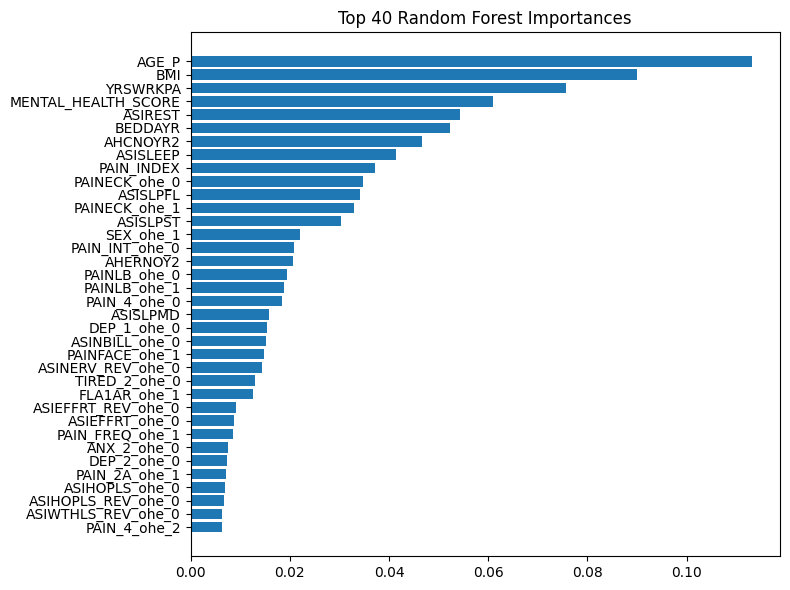


[Summary of Test Performance — Leakage Removed]
                 model       auc  accuracy  precision    recall        f1
0  Logistic Regression  0.804146  0.811967   0.415842  0.578811  0.483976
1        Decision Tree  0.765001  0.777457   0.358391  0.583118  0.443934
2        Random Forest  0.797680  0.815772   0.421965  0.565891  0.483444

[OK] Saved to:
 - /content/drive/MyDrive/Infosys722/iteration4_prep_outputs/dm_summary_allmodels_fixed.csv
 - /content/drive/MyDrive/Infosys722/iteration4_prep_outputs/imp_*_top20.csv
 - /content/drive/MyDrive/Infosys722/iteration4_prep_outputs/dm_top_features_fixed.json
 - /content/drive/MyDrive/Infosys722/iteration4_prep_outputs/figs/: ROC, PR, and Top Feature plots


In [10]:
# ============================================================
# 7. Data Mining — Fixed (no leakage) Model Training & Evaluation
# ============================================================

import os, json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve, roc_curve,
    precision_score, recall_score, f1_score, confusion_matrix, accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# 0) Paths & I/O
# -----------------------------
base_dir = "/content/drive/MyDrive/Infosys722/iteration4_prep_outputs"
os.makedirs(f"{base_dir}/figs", exist_ok=True)

IN = f"{base_dir}/final_selected_table.parquet"
assert os.path.exists(IN), f"Input not found: {IN}"
df = pd.read_parquet(IN)

# -----------------------------
# 1) Remove leakage columns
# -----------------------------
leak_cols = [c for c in df.columns if "AMIGR" in c and c != "AMIGR"]
if leak_cols:
    print(f"[Leakage Warning] Removing {len(leak_cols)} column(s): {leak_cols}")
    df = df.drop(columns=leak_cols)

RID_COL, TARGET_COL = "RID", "AMIGR"
X = df.drop(columns=[RID_COL, TARGET_COL])
y = (df[TARGET_COL] == 1).astype(int)

# Stratified split ensures same positive rate across sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
print(f"[Load] {IN} | shape={df.shape} | positive rate={y.mean():.3f}")

# ============================================================
# Helper Functions
# ============================================================

def best_threshold_f1(y_true, y_proba):
    p, r, thr = precision_recall_curve(y_true, y_proba)
    thr = np.r_[0, thr]
    f1 = 2 * p * r / (p + r + 1e-12)
    i = np.nanargmax(f1)
    return float(thr[i]), float(p[i]), float(r[i]), float(f1[i])

def evaluate_at_threshold(y_true, y_proba, thr):
    y_pred = (y_proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "threshold": thr,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "tp": tp, "fp": fp, "tn": tn, "fn": fn
    }

def plot_roc_pr_curves(y_true, y_proba, model_name):
    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0,1],[0,1],'--',color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC — {model_name}")
    plt.legend(); plt.tight_layout()
    plt.savefig(f"{base_dir}/figs/fig_7_roc_{model_name}.png", dpi=200)
    plt.show()

    # PR
    p, r, _ = precision_recall_curve(y_true, y_proba)
    ap = average_precision_score(y_true, y_proba)
    plt.figure(figsize=(6,5))
    plt.plot(r, p, label=f"AP = {ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall — {model_name}")
    plt.legend(); plt.tight_layout()
    plt.savefig(f"{base_dir}/figs/fig_7_pr_{model_name}.png", dpi=200)
    plt.show()
    return auc, ap

# ============================================================
# Models (no change)
# ============================================================

logit = LogisticRegression(
    solver="saga", penalty="l1", C=0.1,
    class_weight="balanced", max_iter=2000, n_jobs=-1, random_state=42
)
tree = DecisionTreeClassifier(
    max_depth=5, min_samples_split=2, class_weight="balanced", random_state=42
)
forest = RandomForestClassifier(
    n_estimators=400, max_depth=None, min_samples_split=5,
    class_weight="balanced", n_jobs=-1, random_state=42
)

models = {"Logistic Regression": logit, "Decision Tree": tree, "Random Forest": forest}

# ============================================================
# Train & Evaluate
# ============================================================

summary_metrics, important_features = [], {}

for name, model in models.items():
    print(f"\n[Train] {name}")
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]

    auc, ap = plot_roc_pr_curves(y_test, proba, name)
    thr, p, r, f1 = best_threshold_f1(y_test, proba)
    evals = evaluate_at_threshold(y_test, proba, thr)
    evals.update({"model": name, "auc": auc, "ap": ap})
    summary_metrics.append(evals)
    print(f"[Test] {name}: AUC={auc:.3f} | AP={ap:.3f} | F1={f1:.3f}")

    # --- Feature Importance / Coefficients ---
    if name == "Logistic Regression":
        coef = model.coef_.ravel()
        feats = np.array(X.columns)
        top_idx = np.argsort(np.abs(coef))[::-1][:40]
        imp_df = pd.DataFrame({"Feature": feats[top_idx], "Coef": coef[top_idx]})
        imp_df["OddsRatio"] = np.exp(imp_df["Coef"])
        imp_df.to_csv(f"{base_dir}/imp_logit_top40.csv", index=False)
        important_features[name] = imp_df
        plt.figure(figsize=(8,6))
        plt.barh(imp_df["Feature"][::-1], imp_df["Coef"][::-1])
        plt.title("Top 40 Logistic Coefficients (Signed)")
        plt.tight_layout()
        plt.savefig(f"{base_dir}/figs/fig_7_logit_top20.png", dpi=200)
        plt.show()

    elif name == "Decision Tree":
        imp = model.feature_importances_
        feats = np.array(X.columns)
        top_idx = np.argsort(imp)[::-1][:40]
        imp_df = pd.DataFrame({"Feature": feats[top_idx], "Importance": imp[top_idx]})
        imp_df.to_csv(f"{base_dir}/imp_tree_top40.csv", index=False)
        important_features[name] = imp_df
        plt.figure(figsize=(8,6))
        plt.barh(imp_df["Feature"][::-1], imp_df["Importance"][::-1])
        plt.title("Top 40 Decision Tree Importances")
        plt.tight_layout()
        plt.savefig(f"{base_dir}/figs/fig_7_tree_top40.png", dpi=200)
        plt.show()

    elif name == "Random Forest":
        imp = model.feature_importances_
        feats = np.array(X.columns)
        top_idx = np.argsort(imp)[::-1][:40]
        imp_df = pd.DataFrame({"Feature": feats[top_idx], "Importance": imp[top_idx]})
        imp_df.to_csv(f"{base_dir}/imp_forest_top40.csv", index=False)
        important_features[name] = imp_df
        plt.figure(figsize=(8,6))
        plt.barh(imp_df["Feature"][::-1], imp_df["Importance"][::-1])
        plt.title("Top 40 Random Forest Importances")
        plt.tight_layout()
        plt.savefig(f"{base_dir}/figs/fig_7_forest_top40.png", dpi=200)
        plt.show()

# ============================================================
# Save Summary Results
# ============================================================

summary_df = pd.DataFrame(summary_metrics)
summary_df.to_csv(f"{base_dir}/dm_summary_allmodels_fixed.csv", index=False)
print("\n[Summary of Test Performance — Leakage Removed]")
print(summary_df[["model","auc","accuracy","precision","recall","f1"]])

with open(f"{base_dir}/dm_top_features_fixed.json", "w") as f:
    json.dump({k: v["Feature"].tolist() for k, v in important_features.items()}, f, indent=2)

print("\n[OK] Saved to:")
print(f" - {base_dir}/dm_summary_allmodels_fixed.csv")
print(f" - {base_dir}/imp_*_top20.csv")
print(f" - {base_dir}/dm_top_features_fixed.json")
print(f" - {base_dir}/figs/: ROC, PR, and Top Feature plots")